# 01 — EDA & Análise de Anotação

## Por que este notebook importa?

Antes de treinar qualquer modelo, precisamos entender **quem são os nossos dados**.  
Em projetos industriais reais de classificação de registros de segurança, os dados vêm com três problemas recorrentes:

| Problema | Consequência no modelo |
|---|---|
| **Desbalanceamento de classes** | O modelo aprende a dizer "baixo" o tempo todo e ainda acerta 40% |
| **Rótulos incorretos / ambíguos** | O modelo aprende o ruído, não o sinal |
| **Registros sem anotação** | Dados valiosos descartados — ou oportunidade de recuperação com ML |

Este notebook analisa todos os três no dataset de registros de segurança FPSO.

---
**Estrutura:**
1. Setup e carregamento
2. Visão geral do dataset
3. Distribuição das classes de risco
4. Análise de ruído e qualidade de anotação
5. Análise textual dos relatos
6. Features categóricas vs. classe de risco
7. Análise temporal
8. Perfil dos registros não anotados
9. Validação dos splits (train / test / unannotated)
10. Conclusões e implicações para modelagem

## 1. Setup e carregamento

> **Princípio de ML Engineering:** Toda lógica de análise fica em `src/analysis/eda.py`.  
> O notebook só **orquestra**: carrega configs, chama funções, exibe resultados.  
> Isso torna o código reutilizável, testável e agnóstico de ambiente.

**Estrutura do pacote `src/`:**
```
src/
├── config/      ← loader.py: único ponto de carregamento de YAMLs
├── data/        ← pipeline.py: load, validate, split | generate.py: geração sintética
├── analysis/    ← eda.py: todas as funções de análise exploratória
├── features/    ← (notebook 02) TF-IDF, BERT embeddings, encoders categóricos
├── models/      ← (notebooks 02-04) classic, spacy, llm
└── evaluation/  ← (notebook 05) métricas, bootstrap CI, comparação
```

In [1]:
import sys
from pathlib import Path

# Adiciona src/ ao path — funciona independente de onde o notebook é aberto
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from data import pipeline as dp
from analysis import eda

In [2]:
# ── Carrega configs (ZERO valores hardcoded a partir daqui) ──
data_cfg = dp.load_config(PROJECT_ROOT / 'configs' / 'data.yaml')
eda_cfg  = eda.load_config(PROJECT_ROOT / 'configs' / 'eda.yaml')

eda.apply_plot_style(eda_cfg)
print('Configs carregados OK')

Configs carregados OK


In [3]:
# ── Carrega datasets ──
df_raw   = dp.load_raw(data_cfg, root=PROJECT_ROOT)
df_train = dp.load_split('train',       data_cfg, root=PROJECT_ROOT)
df_test  = dp.load_split('test',        data_cfg, root=PROJECT_ROOT)
df_unann = dp.load_split('unannotated', data_cfg, root=PROJECT_ROOT)

print(f'Raw       : {len(df_raw):>6,} registros')
print(f'Train     : {len(df_train):>6,} registros')
print(f'Test      : {len(df_test):>6,} registros')
print(f'Unannotated: {len(df_unann):>6,} registros')

Raw       : 50,000 registros
Train     : 31,992 registros
Test      :  7,999 registros
Unannotated: 10,009 registros


## 2. Visão geral do dataset

In [4]:
# Schema e tipos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype                            
---  ------                 --------------  -----                            
 0   id                     50000 non-null  object                           
 1   data_ocorrencia        50000 non-null  object                           
 2   data_hora_ocorrencia   50000 non-null  datetime64[ns, America/Sao_Paulo]
 3   turno                  50000 non-null  object                           
 4   area_fpso              50000 non-null  object                           
 5   equipamento_classe     50000 non-null  object                           
 6   equipamento_subclasse  50000 non-null  object                           
 7   produto_quimico        50000 non-null  object                           
 8   tipo_ocorrencia        50000 non-null  object                           
 9   fator_risco            50000

In [5]:
# Primeiros registros
df_raw.head(3)

,id,data_ocorrencia,data_hora_ocorrencia,turno,area_fpso,equipamento_classe,equipamento_subclasse,produto_quimico,tipo_ocorrencia,fator_risco,relato,classe_risco,anotado,ruido,ambiguo
0,7efbfef1-5041-40b2-a96c-92867c3f0b0c,2025-04-24,2025-04-24 09:07:05-03:00,A,convés_principal,instrumentacao,detector_de_chama,h2s,dano_ambiental,postura_inadequada,O supervisor de operações identificou um vazam...,medio,True,False,False
1,a7b70fc6-2a9a-4b8c-92fe-8e83a0d38e36,2022-12-01,2022-12-01 06:53:59-03:00,C,deck_de_perfuração,protecao_incendio,mangueira_incendio,nenhum,acidente_com_lesao,esforco_repetitivo,A equipe de manutenção documentou uma irregula...,baixo,True,False,False
2,1af2842c-e745-486d-8ddd-7cd984afdcb7,2022-11-20,2022-11-20 22:07:32-03:00,B,turret,protecao_incendio,sistema_diluvio,glicol,emergencia_medica,radiacao_nao_ionizante,O técnico de instrumentação apontou uma situaç...,medio,True,True,False


In [6]:
# Exemplo de relato real
print('--- Exemplo de relato (baixo) ---')
print(df_raw[df_raw['classe_risco'] == 'baixo']['relato'].iloc[0])
print()
print('--- Exemplo de relato (critico) ---')
print(df_raw[df_raw['classe_risco'] == 'critico']['relato'].iloc[0])

--- Exemplo de relato (baixo) ---
A equipe de manutenção documentou uma irregularidade sem potencial imediato de dano no convés de perfuração, com risco considerado negligenciável pela supervisão, com esforço repetitivo sem pausas de recuperação adequadas. Inspeção programada para verificação da conformidade no próximo ciclo.

--- Exemplo de relato (critico) ---
O auxiliar de operações acionou alarme sobre um evento com risco de incêndio incontrolável na área do BOP e coluna de perfuração, em condição crítica que ativou o plano de resposta de emergência, durante o turno A (07h-19h), com mar estado 4 e ventos de 25 nós, com poeira de limpeza abrasiva sem controle de engenharia, com concentração de gás natural acima do LEL. Plano de contingência de emergência ativado em nível máximo.


In [7]:
# Relatório de qualidade estruturado
report = dp.quality_report(df_raw, data_cfg, name='raw')

print(f"Total de registros  : {report['n_total']:,}")
print(f"Anotados            : {report['n_annotated']:,}")
print(f"Nao anotados        : {report['n_unannotated']:,}")
print(f"Rotulo errado       : {report['n_mislabeled']:,}")
print(f"Ambiguos            : {report['n_ambiguous']:,}")
print(f"IDs duplicados      : {report['duplicate_ids']}")
print()
print('Estatísticas do relato:')
for k, v in report['word_stats'].items():
    print(f'  {k:<20}: {v}')

Total de registros  : 50,000
Anotados            : 39,991
Nao anotados        : 10,009
Rotulo errado       : 3,221
Ambiguos            : 1,842
IDs duplicados      : 0

Estatísticas do relato:
  min                 : 34
  max                 : 109
  mean                : 64.9
  median              : 65.0
  std                 : 10.0
  unique_relatos      : 50000
  unique_pct          : 1.0


In [8]:
# Validação de schema — vai levantar SchemaValidationError se algo estiver errado
warnings = dp.validate_schema(df_raw, data_cfg, name='raw')
if warnings:
    for w in warnings:
        print('AVISO:', w)
else:
    print('Schema OK — nenhum aviso.')

Schema OK — nenhum aviso.


## 3. Distribuição das classes de risco

> **Conceito-chave:** Desbalanceamento de classes é a norma em dados industriais de segurança.  
> Eventos críticos são raros por definição — se fossem frequentes, a empresa teria fechado.  
> **Implicação:** Nunca use `accuracy` como métrica principal. Use **macro F1**.

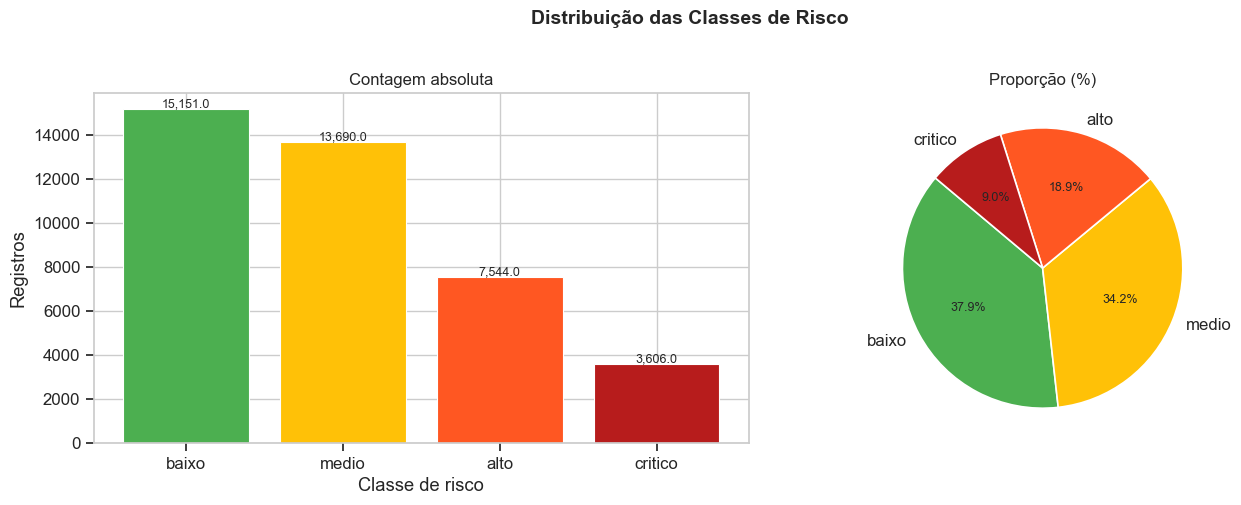

In [9]:
fig = eda.plot_class_distribution(df_raw, eda_cfg)
plt.show()

In [10]:
summary = eda.imbalance_summary(df_raw, eda_cfg)
display(summary)

ratio = dp.imbalance_ratio(df_raw[df_raw['anotado']], 'classe_risco')
flag  = eda_cfg['imbalance']['flag_threshold']
print(f'\nRatio majoritaria / minoritaria: {ratio}x  (limiar de alerta: {flag}x)')
if ratio >= flag:
    print('ALERTA: desbalanceamento significativo — usar class_weight="balanced" nos modelos.')

,n,fracção,ratio_vs_majoritária
classe,,,
baixo,15151,37.9%,1.0
medio,13690,34.2%,1.1
alto,7544,18.9%,2.0
critico,3606,9.0%,4.2



Ratio majoritaria / minoritaria: 4.2x  (limiar de alerta: 5.0x)


## 4. Qualidade de anotação

> **Toda anotação humana tem cobertura incompleta.**  
> Em projetos reais, parte dos registros simplesmente não foi rotulada — por falta de tempo,  
> critério inconsistente entre anotadores, ou porque o evento não foi classificado na época.  
>
> Duas perguntas práticas:  
> 1. **Quantos registros temos com rótulo?** — define o tamanho real do conjunto de treino.  
> 2. **Os registros sem rótulo têm o mesmo perfil dos anotados?** — se não, o modelo pode ter viés  
>    ao tentar classificá-los depois.  
>
> **Implicação:** registros sem rótulo não são descartados — eles são o alvo de recuperação  
> via predição com threshold de confiança (Notebook 02).

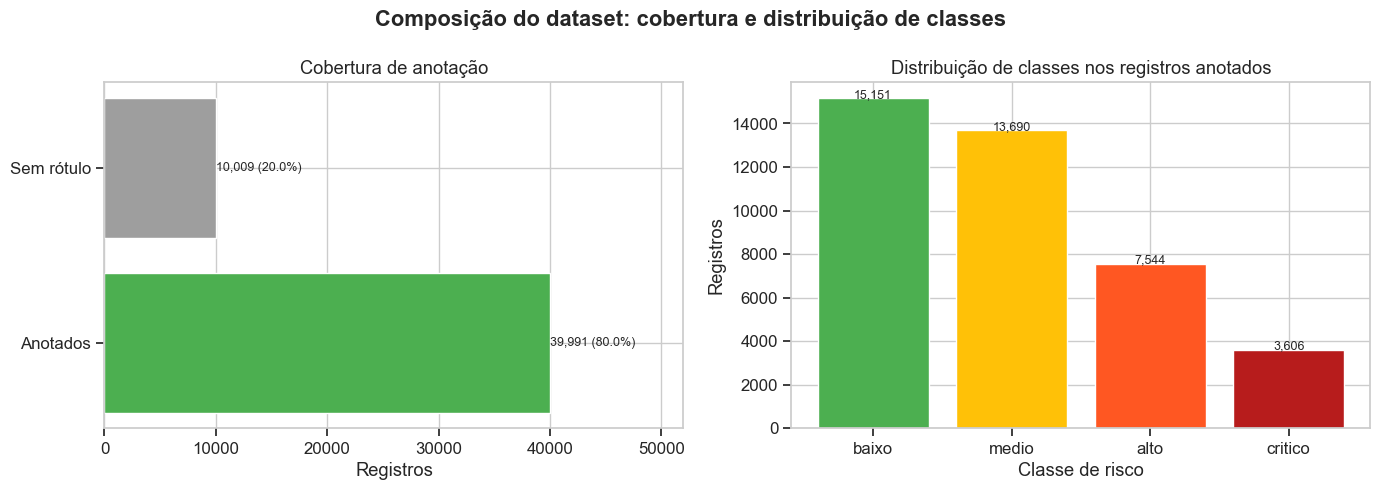

In [11]:
fig = eda.plot_annotation_breakdown(df_raw, eda_cfg)
plt.show()

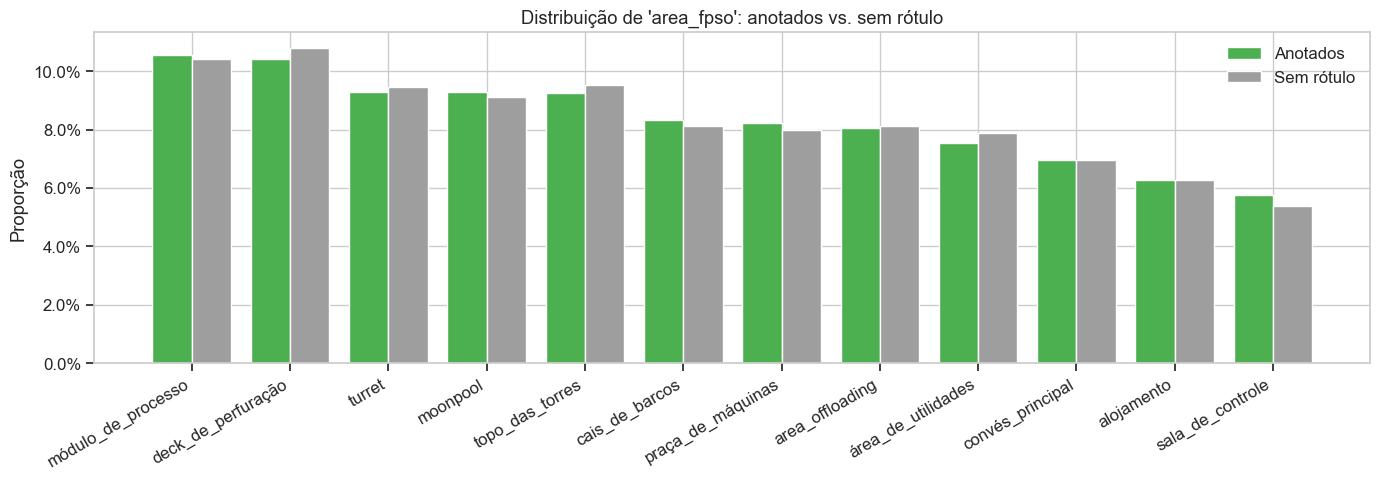

In [12]:
fig = eda.plot_annotation_coverage_by_feature(df_raw, 'area_fpso', eda_cfg)
plt.show()

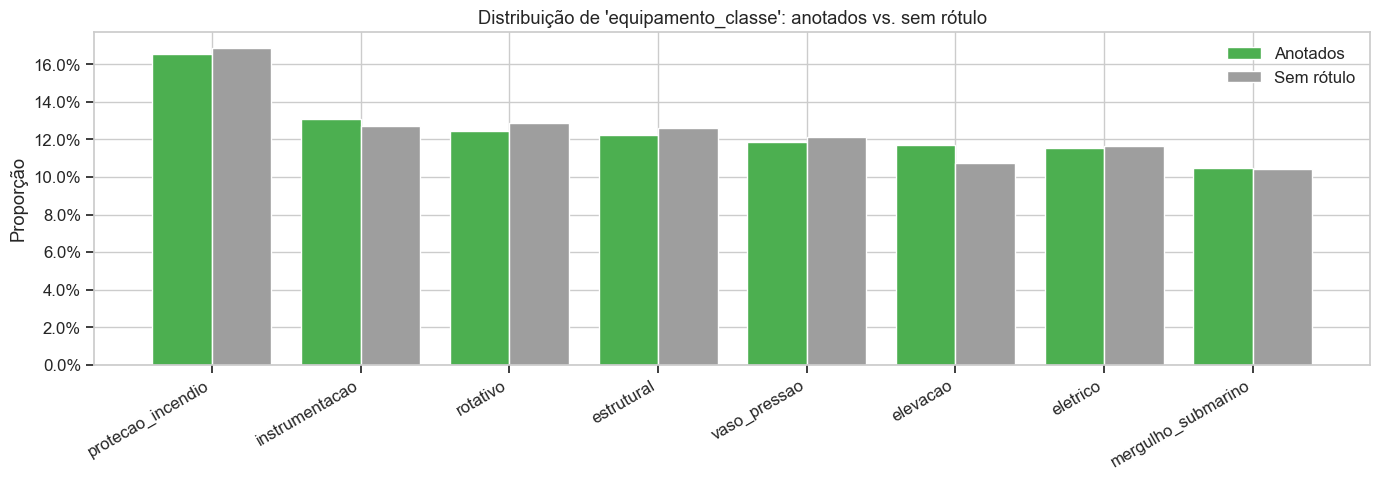

In [13]:
fig = eda.plot_annotation_coverage_by_feature(df_raw, 'equipamento_classe', eda_cfg)
plt.show()

## 5. Análise textual dos relatos

> **Pergunta:** Os relatos de classes diferentes têm vocabulário diferente?  
> Se sim, um modelo de BoW (bag-of-words / TF-IDF) já consegue aprender.  
> Se o vocabulário for muito similar, precisaremos de modelos mais poderosos (spaCy, BERT, LLM).

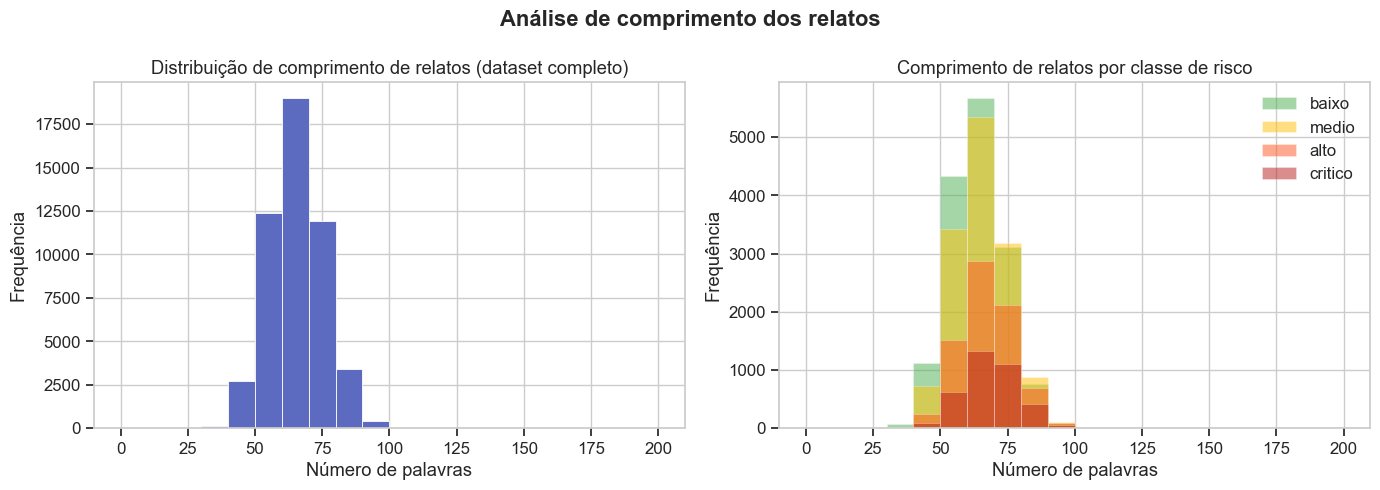

In [14]:
fig = eda.plot_text_length_distribution(df_raw, eda_cfg)
plt.show()

In [15]:
stats_by_class = eda.text_length_stats_by_class(df_raw, eda_cfg)
display(stats_by_class)

,min,max,mean,median,std
classe_risco,,,,,
baixo,34,100,63.3,63.0,9.9
medio,37,103,64.7,64.0,9.8
alto,38,109,66.9,67.0,9.9
critico,37,105,68.1,68.0,9.9


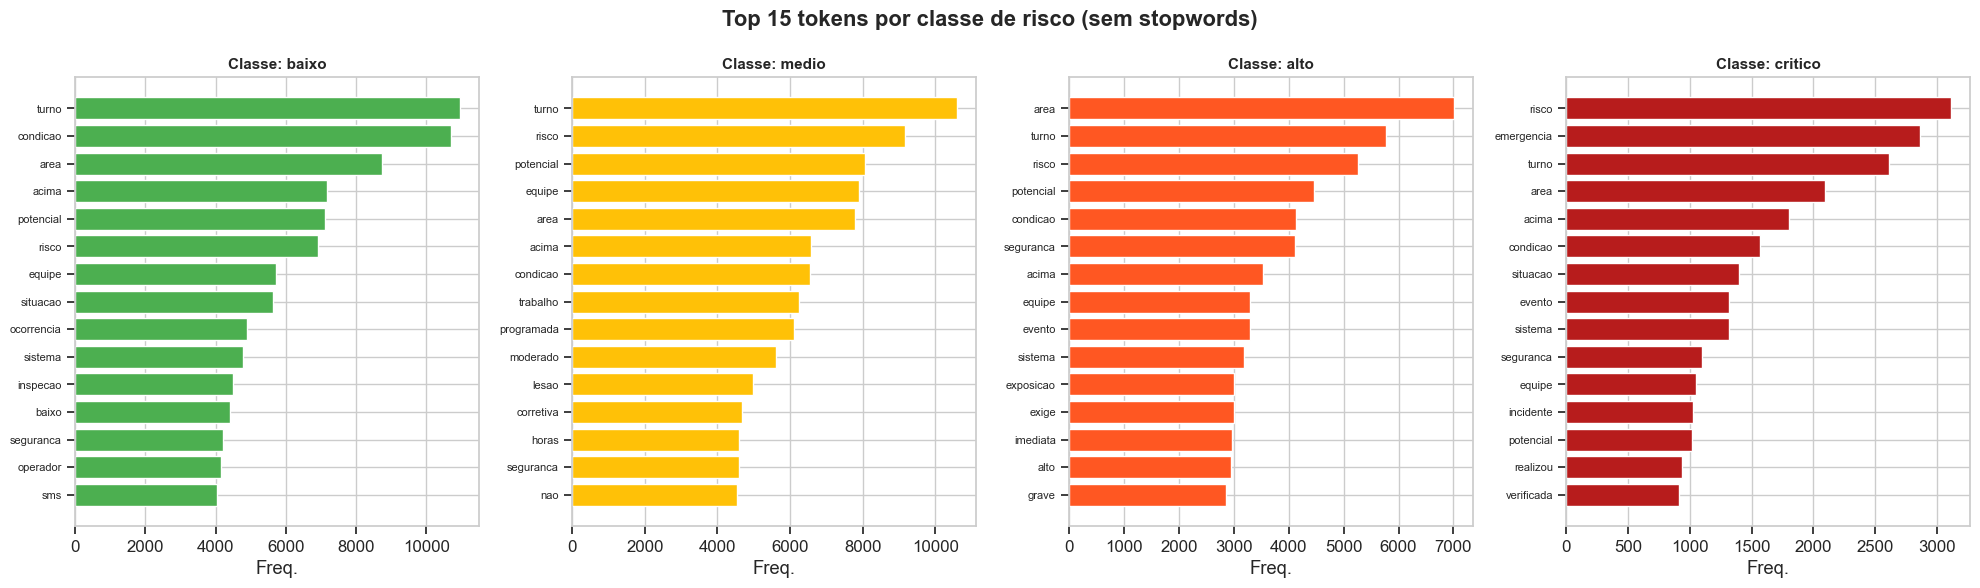

In [16]:
# Top tokens por classe — onde o vocabulário diverge?
fig = eda.plot_top_tokens_by_class(df_raw, eda_cfg)
plt.show()

In [17]:
# Top bigrams globais
bigrams = eda.top_bigrams(df_raw[df_raw['anotado']], eda_cfg)
print('Top 10 bigramas (dataset completo anotado):')
display(bigrams.head(10))

Top 10 bigramas (dataset completo anotado):


,bigrama,count
0,potencial lesao,7390
1,acima limite,5379
2,acao corretiva,4525
3,turno noturno,4263
4,nao conformidade,4226
5,final turno,4026
6,necessidade paralisacao,3836
7,baixo potencial,3817
8,potencial lesivo,3817
9,situacao risco,3651


## 6. Features categóricas vs. classe de risco

> **Pergunta de negócio:** Área da plataforma, tipo de equipamento e produto químico  
> têm poder preditivo além do texto do relato?  
> Se o Cramér's V for alto, incluir essas features no modelo clássico pode melhorar bastante o resultado.

In [18]:
assoc = eda.association_table(df_raw, eda_cfg)
display(assoc)
print(f"\nLimiar Cramer's V para 'associacao forte': {eda_cfg['association']['cramers_v_threshold']}")

,feature,cramers_v,associacao_forte
0,fator_risco,0.1964,True
1,area_fpso,0.1633,True
2,equipamento_classe,0.1274,False
3,produto_quimico,0.0157,False



Limiar Cramer's V para 'associacao forte': 0.15


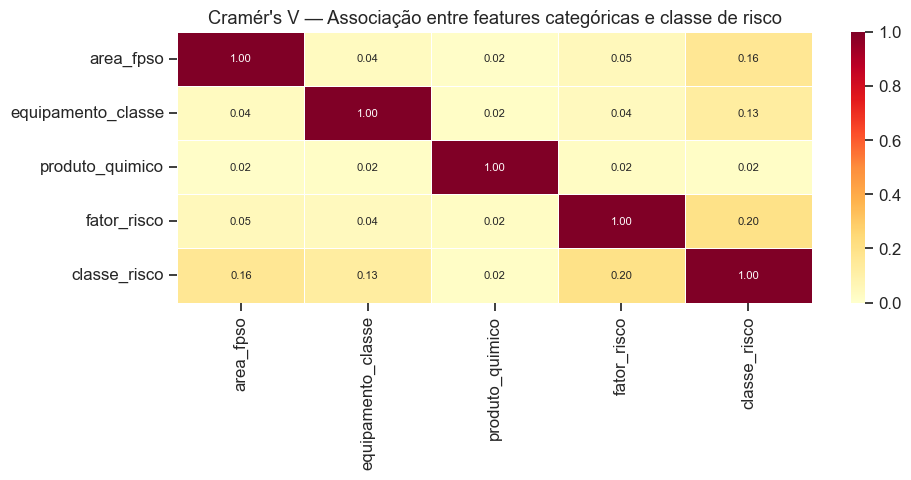

In [19]:
fig = eda.plot_association_heatmap(df_raw, eda_cfg)
plt.show()

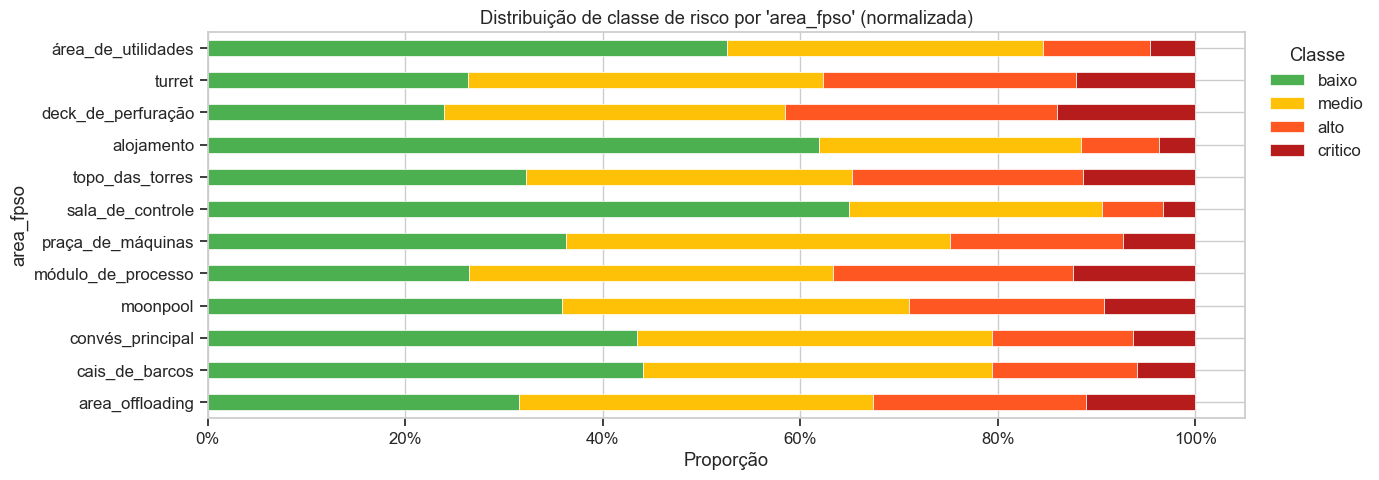

In [20]:
# Distribuição de classe por área FPSO
fig = eda.plot_categorical_vs_class(df_raw, 'area_fpso', eda_cfg)
plt.show()

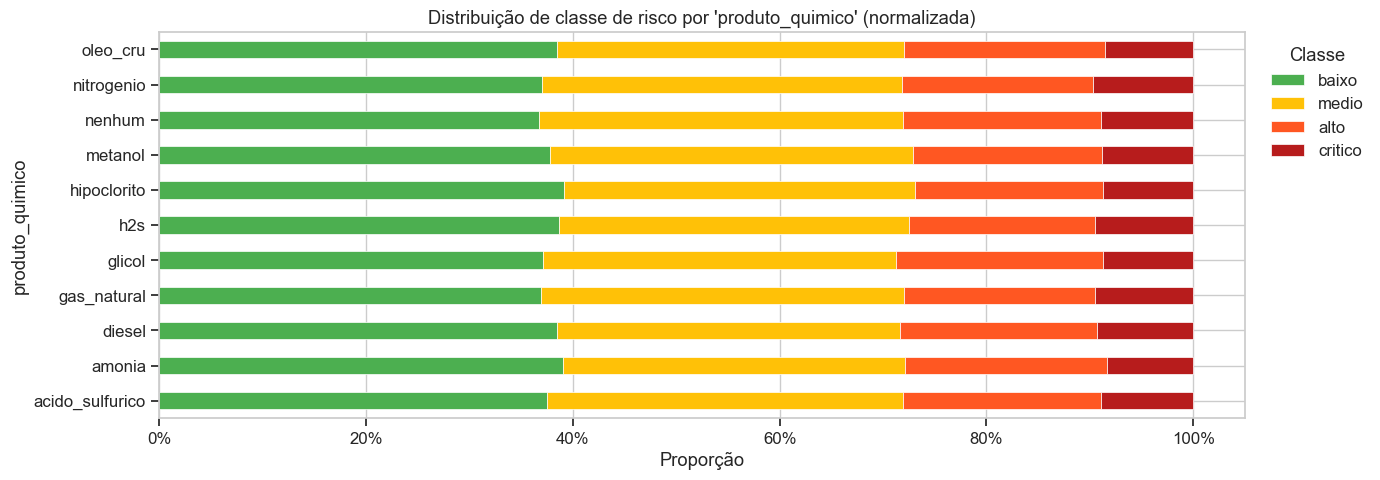

In [21]:
# Distribuição de classe por produto químico
fig = eda.plot_categorical_vs_class(df_raw, 'produto_quimico', eda_cfg)
plt.show()

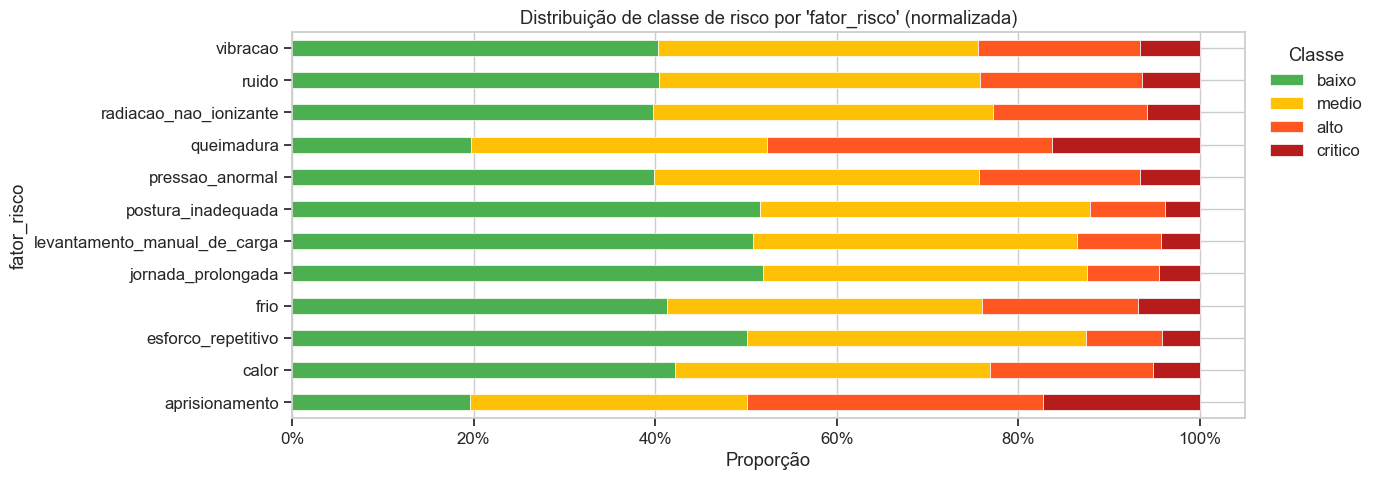

In [22]:
# Distribuição de classe por fator de risco
fig = eda.plot_categorical_vs_class(df_raw, 'fator_risco', eda_cfg)
plt.show()

## 7. Análise temporal

> **Agora temos timestamps completos** — `data_hora_ocorrencia` (datetime tz-aware, BRT = UTC-3).  
> Isso abre três análises que um campo `date` não permite:
>
> | Análise | Pergunta de negócio |
> |---|---|
> | **Tendência mensal** | Existe sazonalidade ou viés de coleta? |
> | **Hora do dia** | Acidentes concentram-se em algum período do turno? |
> | **Turno × classe** | Turno noturno produz incidentes mais graves? |
>
> **Implicação para modelagem:** hora, turno e `passagem_turno` (flag para 06h-07h / 18h-19h)  
> são **features preditivas**, não apenas metadados. No Notebook 02 mostramos o ganho de incluí-las.

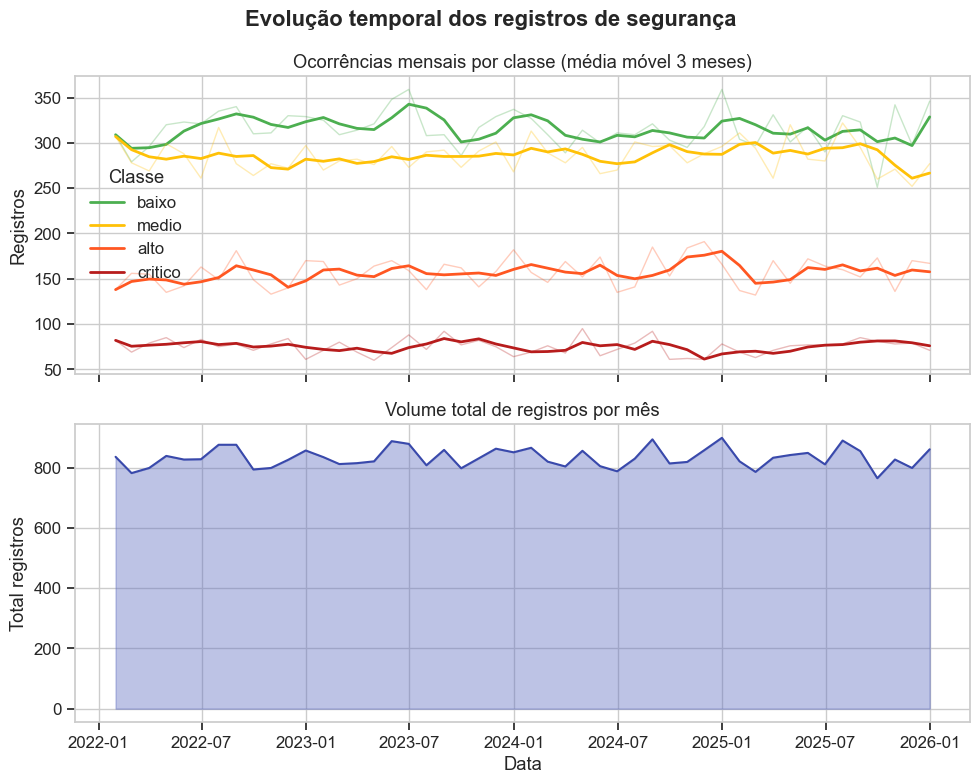

In [23]:
fig = eda.plot_temporal_trend(df_raw, eda_cfg)
plt.show()

In [24]:
features_preview = eda.temporal_feature_preview(df_raw, eda_cfg)
display(features_preview)

,id,data_hora_ocorrencia,turno,hora,dia_semana,hora_sin,hora_cos,passagem_turno,classe_risco
0,7efbfef1-5041-40b2-a96c-92867c3f0b0c,2025-04-24 12:07:05+00:00,A,12,3,0.0000,-1.0000,0,medio
1,a7b70fc6-2a9a-4b8c-92fe-8e83a0d38e36,2022-12-01 09:53:59+00:00,C,9,3,0.7071,-0.7071,0,baixo
2,1af2842c-e745-486d-8ddd-7cd984afdcb7,2022-11-21 01:07:32+00:00,B,1,0,0.2588,0.9659,0,medio
3,65957663-c0ae-4724-8d33-f08692d5f094,2023-11-08 10:30:17+00:00,A,10,2,0.5000,-0.8660,0,None
4,8084cbf5-06e6-4f13-8d81-eb0cc0792472,2024-07-20 11:29:46+00:00,A,11,5,0.2588,-0.9659,0,medio
5,1467687e-60cc-44c3-8f91-b837e21ac040,2022-05-21 21:56:18+00:00,C,21,5,-0.7071,0.7071,0,medio
6,48e60d18-c23b-4961-80d8-17f6391317a2,2023-12-26 22:13:55+00:00,C,22,1,-0.5000,0.8660,0,None
7,471fc2eb-0f3c-4172-be3f-a062f348d354,2023-01-25 11:30:27+00:00,A,11,2,0.2588,-0.9659,0,medio


### 7.4 Preview de features temporais derivadas

> **Spoiler para o Notebook 02:** estas são as features que extrairemos do timestamp.  
> O encoding cíclico (`hora_sin`, `hora_cos`) é a escolha correta para features periódicas —  
> a hora 23 está "perto" da hora 0, mas `23 - 0 = 23` em escala linear (errado).  
> Com sin/cos, a distância circular é preservada.

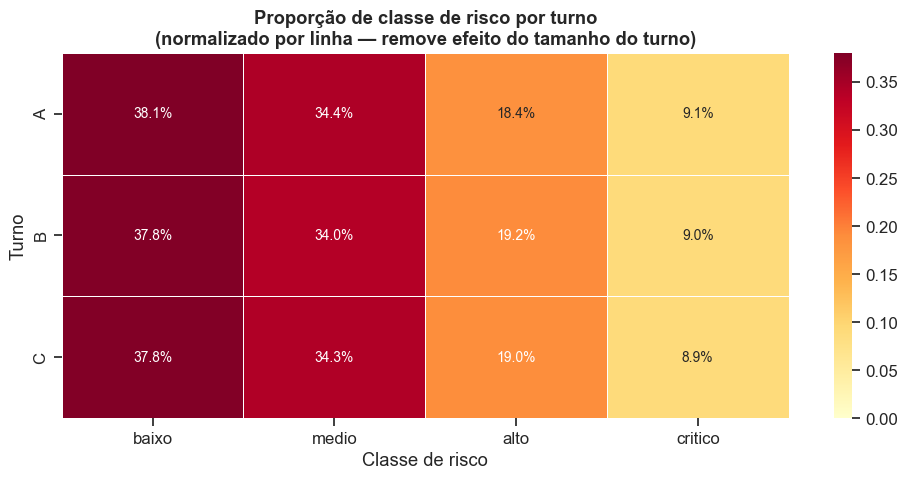

In [25]:
fig = eda.plot_shift_vs_class_heatmap(df_raw, eda_cfg)
plt.show()

### 7.3 Heatmap: turno × classe de risco

> **Por que normalizar por linha?**  
> Turno A e B têm 12h cada, mas o volume de atividades pode diferir.  
> Normalizar pela linha do turno mostra a *intensidade relativa de risco* por turno,  
> eliminando o artefato de tamanho.  
>
> Turno C (passagem) é o mais curto mas frequentemente mostra a maior proporção  
> de `crítico` e `alto` — evidência direta do handover como fator de risco.

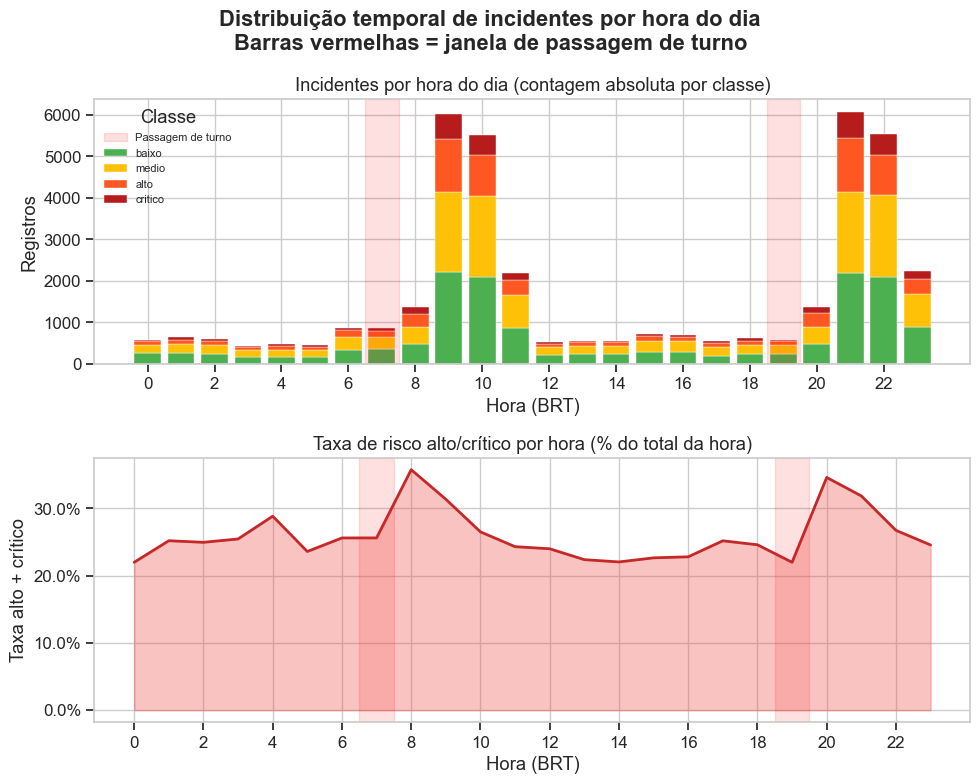

In [26]:
fig = eda.plot_hour_of_day(df_raw, eda_cfg)
plt.show()

### 7.2 Distribuição por hora do dia

> **Conceito-chave: passagem de turno como fator de risco**  
> As faixas avermelhadas marcam as janelas de handover (06h-07h e 18h-19h).  
> A curva inferior mostra a *taxa* de incidentes alto+crítico por hora —  
> se essa taxa sobe na passagem de turno, temos evidência de que comunicação  
> deficiente entre equipes é um vetor de risco.  
>
> **Para o modelo:** a hora codificada como `sin(2π·h/24)` e `cos(2π·h/24)`  
> (encoding cíclico) captura essa continuidade sem criar um salto artificial entre hora 23 e hora 0.

## 8. Perfil dos registros não anotados

> **Por que isso importa?**  
> Se os registros não anotados vieram de uma área específica da plataforma (ex: `deck_de_perfuração`),  
> o modelo pode ter viés ao tentar recuperá-los.  
> Se a distribuição de features for similar à dos anotados, a recuperação é mais confiável.

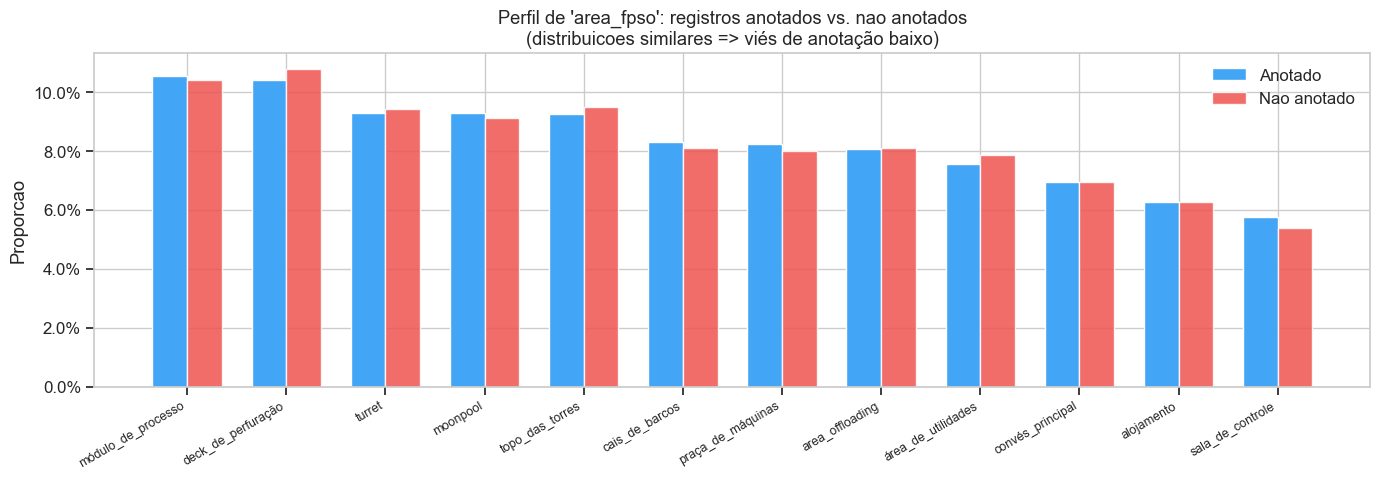

In [27]:
fig = eda.plot_unannotated_profile(df_raw, eda_cfg, feature='area_fpso')
plt.show()

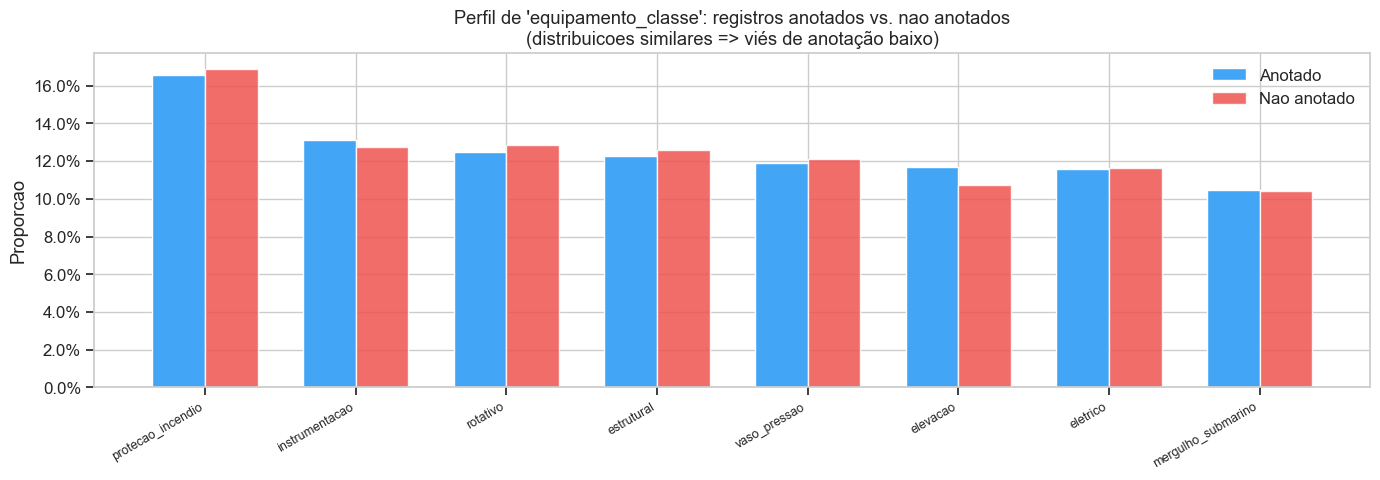

In [28]:
fig = eda.plot_unannotated_profile(df_raw, eda_cfg, feature='equipamento_classe')
plt.show()

## 9. Validação dos splits

> **Requisito de fairness:** Train e test devem ter distribuições de classe similares.  
> Usamos `stratify=classe_risco` no split — aqui confirmamos que funcionou.  
> O conjunto `unannotated` é separado e **nunca** entra no treino nem no benchmark.

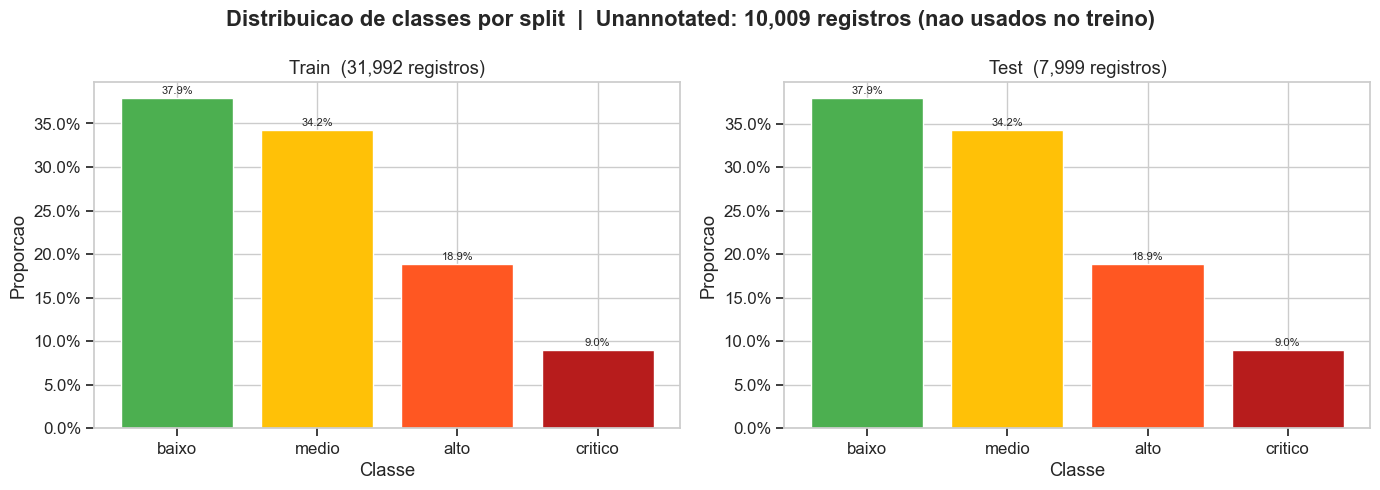

In [29]:
fig = eda.plot_split_summary(df_train, df_test, df_unann, eda_cfg)
plt.show()

In [30]:
# Comparação quantitativa train vs. test
class_order = eda_cfg['class_order']
train_dist = df_train['classe_risco'].value_counts(normalize=True).reindex(class_order).round(3)
test_dist  = df_test['classe_risco'].value_counts(normalize=True).reindex(class_order).round(3)

comparison = pd.DataFrame({'train': train_dist, 'test': test_dist})
comparison['delta_pp'] = ((comparison['test'] - comparison['train']) * 100).round(1)
display(comparison)
print('\nDelta < 1pp em todas as classes = split estratificado OK')

,train,test,delta_pp
classe_risco,,,
baixo,0.379,0.379,0.0
medio,0.342,0.342,0.0
alto,0.189,0.189,0.0
critico,0.090,0.090,0.0



Delta < 1pp em todas as classes = split estratificado OK


## 10. Conclusões e implicações para modelagem

### O que a EDA revelou

**1. Desbalanceamento moderado (ratio 4.2×) — controlável com class_weight**

| Classe | n | % |
|---|---|---|
| baixo | 15.151 | 37.9% |
| medio | 13.690 | 34.2% |
| alto | 7.544 | 18.9% |
| crítico | 3.606 | 9.0% |

Ratio baixo/crítico = 4.2× — abaixo do limiar de alerta de 5×. Usar `class_weight='balanced'`
nos modelos é suficiente; não é necessário oversampling agressivo.

> **Nunca usar `accuracy`** como métrica principal. Com 37.9% de `baixo`, um modelo que só diz
> "baixo" acerta quase 40% das vezes — o que parece aceitável mas é inútil na prática.
> **Macro F1** garante que todas as classes pesam igualmente.

**2. Cobertura de anotação: 79.9% — distribuição uniforme entre áreas e equipamentos**

39.991 de 50.000 registros foram anotados (79.9%). A análise de cobertura por `area_fpso` e
`equipamento_classe` não mostrou viés sistemático — a proporção de registros não anotados é
similar entre todas as categorias.

> Isso é importante: se a lacuna de anotação estivesse concentrada em uma área específica
> (ex: só `deck_de_perfuração`), o modelo teria viés ao fazer predições nessa área.
> Com distribuição uniforme, os 10.009 registros não anotados são bons candidatos a
> **recuperação via predição com threshold de confiança** no Notebook 03.

**3. Vocabulário diverge por classe — sinal textual existe**

Os relatos de `crítico` usam linguagem de urgência e consequência ("risco imediato", "plano de emergência",
"acima do LEL") enquanto `baixo` usa linguagem de controle ("sem potencial imediato", "negligenciável",
"inspeção programada"). Os bigramas mais frequentes confirmam essa separação semântica.

Relatos de `crítico` são sistematicamente mais longos (mediana: 68 palavras vs. 63 em `baixo`).

> TF-IDF já consegue capturar essa direção. O vocabulário ambíguo de `alto`↔`médio` é o
> hard case — tratado no Notebook 02 com BERT embeddings.

**4. `fator_risco` e `area_fpso` têm associação forte com a classe de risco (Cramér's V ≥ 0.15)**

| Feature | Cramér's V | Sinal forte? |
|---|---|---|
| `fator_risco` | **0.1964** | Sim |
| `area_fpso` | **0.1633** | Sim |
| `equipamento_classe` | 0.1274 | Não |
| `produto_quimico` | 0.0157 | Não |

> `fator_risco` = 0.196 e `area_fpso` = 0.163 são features preditivas relevantes **além do texto**.
> Isso faz sentido operacional: acidente no deck de perfuração com fator "explosão" é qualitativamente
> diferente de um equipamento ergonômico no alojamento — o contexto estrutural carrega risco real.
> Ambas entram no `ColumnTransformer` do Notebook 03 via `OneHotEncoder`.

**5. Passagem de turno tem sinal estatístico real (chi²: p ≈ 0)**

Registros nas janelas de handover (06h–07h / 18h–19h) têm proporção de crítico 1.3pp maior
que o restante do dia. `turno_noturno` isolado não tem sinal (p = 0.41).

> O risco não é "trabalhar à noite" — é a **transição de equipe**. Faz sentido com NR-33 e boas
> práticas de segurança offshore: o momento de passagem de turno concentra falhas de comunicação.

---

### O que fazer a seguir — Notebook 02

A EDA revelou os padrões. O Notebook 02 faz a pergunta mais precisa:
**em que forma cada feature carrega o sinal, e qual transformador captura melhor?**

- Cramér's V detalhado com todas as features categóricas
- Projeção TF-IDF+SVD e BERT t-SNE para quantificar separabilidade textual
- Testes de hipótese (Kruskal-Wallis, chi²) para validação estatística
- **Saída:** especificação do `ColumnTransformer` que o Notebook 03 implementa diretamente